# PV Development Suitability with MaxEnt

This notebook implements presence-background sampling and spatially explicit validation for a national-scale photovoltaic development-suitability model.

## Outline

1. Configure inputs and analysis settings
2. Load and prepare predictor and presence data
3. Sample a uniform study-area background
4. Assign 2-degree spatial cross-validation folds
5. Evaluate candidate MaxEnt configurations
6. Plot fold-specific and pooled ROC curves
7. Export a concise validation summary


## 1. Configuration

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from elapid import MaxentModel
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from sklearn.neighbors import BallTree

SEED = 20260913
AREA_THRESHOLD_KM2 = 0.3
BACKGROUND_N = 30_000
PRESENCE_EXCLUSION_KM = 8.0
N_FOLDS = 5
BLOCK_DEGREES = 2.0

INPUT_FEATHER = Path(r"F:\NDVI\v2\NDVI_Final_Prediction_Full.feather")
PRESENCE_CSV = Path(r"D:\小区光伏物候研究\重做\预测数据\最终汇总结果_含道路面积PVOUT及LUCC.csv")
OUTPUT_DIR = Path.cwd() / "PV_MaxEnt_upload_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BACKGROUND_CSV = OUTPUT_DIR / "background_points_uniform_30k.csv"
CV_CSV = OUTPUT_DIR / "spatial_cv_candidate_models.csv"
OOF_CSV = OUTPUT_DIR / "spatial_oof_predictions.csv"
ROC_FIGURE = OUTPUT_DIR / "spatial_cross_validation_roc.png"
SUMMARY_JSON = OUTPUT_DIR / "validation_summary.json"

print(f"Random seed: {SEED}")
print(f"Output directory: {OUTPUT_DIR.name}")


Random seed: 20260913
Output directory: PV_MaxEnt_upload_outputs


## 2. Load and prepare the data

In [2]:
full = pd.read_feather(INPUT_FEATHER)
presence_raw = pd.read_csv(PRESENCE_CSV)

rename_map = {
    "GDP": "GDP2020",
    "LUCC": "LUCC2020",
    "Grid_Distance": "GRID_Distance",
    "grid_distance": "GRID_Distance",
    "Lon": "lon",
    "Lat": "lat",
}
full = full.rename(columns=rename_map)
presence_raw = presence_raw.rename(columns=rename_map)

exact_area_columns = [
    column for column in presence_raw.columns
    if column in {"面积KM", "面积km", "Area_km2"}
]
if exact_area_columns:
    area_column = exact_area_columns[0]
else:
    area_candidates = [
        column for column in presence_raw.columns
        if "KM" in str(column).upper()
        and column != "Station_ID"
        and pd.api.types.is_numeric_dtype(presence_raw[column])
    ]
    if len(area_candidates) != 1:
        raise KeyError(f"Could not uniquely identify the area column: {area_candidates}")
    area_column = area_candidates[0]

presence_raw = presence_raw.rename(columns={area_column: "Area_km2"})
presence = presence_raw.loc[
    pd.to_numeric(presence_raw["Area_km2"], errors="coerce") >= AREA_THRESHOLD_KM2
].copy()

for frame in (full, presence):
    aspect = pd.to_numeric(frame["Aspect"], errors="coerce").to_numpy(float)
    flat = aspect == -1
    valid_aspect = (~flat) & np.isfinite(aspect) & (aspect >= 0) & (aspect <= 360)
    northness = np.full(len(frame), np.nan, dtype=float)
    eastness = np.full(len(frame), np.nan, dtype=float)
    northness[flat] = 0.0
    eastness[flat] = 0.0
    northness[valid_aspect] = np.cos(np.deg2rad(aspect[valid_aspect]))
    eastness[valid_aspect] = np.sin(np.deg2rad(aspect[valid_aspect]))
    frame["Aspect_Northness"] = northness
    frame["Aspect_Eastness"] = eastness

required_columns = [
    "lon", "lat", "Aspect_Northness", "Aspect_Eastness", "Slope",
    "PVOUT", "Road_Distance", "GRID_Distance",
]
full_valid = full.loc[
    (full["NDVIscale"] >= 0) & full[required_columns].notna().all(axis=1)
].copy()
presence = presence.loc[presence[required_columns].notna().all(axis=1)].copy()

if presence.empty:
    raise RuntimeError("No presence records remain after filtering.")

print(f"Source presence records: {len(presence_raw):,}")
print(f"Filtered presence records: {len(presence):,}")
print(f"Valid study-area pixels: {len(full_valid):,}")
display(presence[required_columns + ["Area_km2"]].head())


Source presence records: 12,314
Filtered presence records: 1,296
Valid study-area pixels: 555,850


,lon,lat,Aspect_Northness,Aspect_Eastness,Slope,PVOUT,Road_Distance,GRID_Distance,Area_km2
31,116.342568,31.633784,-0.956498,-0.291740,0.087088,1127.162,7216.8467,4435.2300,0.457356
40,117.651102,31.687390,-0.849460,0.527654,0.451026,1155.651,0.0000,4392.7390,0.799075
42,117.735684,31.695842,0.172858,0.984947,0.501755,1154.190,1896.0885,0.0000,0.314893
54,114.743580,39.984307,0.319165,0.947699,0.310971,1578.976,1708.4955,1708.0573,1.159377
96,95.192812,36.386023,0.977378,-0.211499,0.776720,1742.973,6895.6514,0.0000,0.893977


## 3. Sample the background

In [3]:
earth_radius_km = 6371.0088
presence_tree = BallTree(
    np.deg2rad(presence[["lat", "lon"]].to_numpy(float)),
    metric="haversine",
)
nearest_distance_rad, _ = presence_tree.query(
    np.deg2rad(full_valid[["lat", "lon"]].to_numpy(float)),
    k=1,
)
nearest_km = nearest_distance_rad[:, 0] * earth_radius_km

eligible = full_valid.loc[nearest_km >= PRESENCE_EXCLUSION_KM].copy()
if len(eligible) < BACKGROUND_N:
    raise RuntimeError("The eligible background pool is smaller than the requested sample.")

background = eligible.sample(
    n=BACKGROUND_N,
    replace=False,
    random_state=SEED,
).copy()
background["occurrence"] = 0
presence["occurrence"] = 1
background.to_csv(BACKGROUND_CSV, index=False, encoding="utf-8-sig")

background_positions = full_valid.index.get_indexer(background.index)
minimum_distance = nearest_km[background_positions].min()

print(f"Eligible background pool: {len(eligible):,}")
print(f"Sampled background points: {len(background):,}")
print(f"Duplicate grid cells: {background.duplicated(['row', 'col']).sum():,}")
print(f"Minimum background-to-presence distance: {minimum_distance:.3f} km")


Eligible background pool: 545,705
Sampled background points: 30,000
Duplicate grid cells: 0
Minimum background-to-presence distance: 8.006 km


## 4. Assign spatial cross-validation folds

In [4]:
model_columns = [
    "occurrence", "lon", "lat", "Aspect_Northness", "Aspect_Eastness",
    "Slope", "PVOUT", "Road_Distance", "GRID_Distance",
]
data = pd.concat(
    [presence[model_columns], background[model_columns]],
    ignore_index=True,
)

data["block_x"] = np.floor(
    (data["lon"].to_numpy(float) - 70.0) / BLOCK_DEGREES
).astype(np.int64)
data["block_y"] = np.floor(
    (data["lat"].to_numpy(float) - 15.0) / BLOCK_DEGREES
).astype(np.int64)
data["fold"] = (
    (data["block_x"] * 73856093 + data["block_y"] * 19349663) % N_FOLDS
).astype(np.int8)

if data.groupby(["block_x", "block_y"])["fold"].nunique().max() != 1:
    raise RuntimeError("At least one spatial block was split across folds.")

fold_counts = (
    data.groupby(["fold", "occurrence"]).size()
    .unstack(fill_value=0)
    .rename(columns={0: "background", 1: "presence"})
)
fold_counts.index = fold_counts.index + 1
fold_counts.index.name = "fold"
display(fold_counts)


occurrence,background,presence
fold,,
1,6071,311
2,5694,286
3,6519,280
4,5657,183
5,6059,236


## 5. Evaluate candidate MaxEnt configurations

In [5]:
candidates = []
feature_sets = {
    "core5": ["Aspect_Northness", "Slope", "PVOUT", "Road_Distance", "GRID_Distance"],
    "circular6": ["Aspect_Northness", "Aspect_Eastness", "Slope", "PVOUT", "Road_Distance", "GRID_Distance"],
}
model_settings = [
    (["linear", "quadratic"], 1.0),
    (["linear", "quadratic"], 2.0),
    (["linear", "quadratic", "hinge"], 1.5),
    (["linear", "quadratic", "hinge"], 2.5),
    (["linear", "quadratic", "hinge", "product"], 2.0),
]

for feature_set_name, feature_names in feature_sets.items():
    for feature_types, beta in model_settings:
        candidates.append({
            "name": feature_set_name,
            "features": feature_names,
            "feature_types": feature_types,
            "beta": beta,
        })

cv_rows = []
candidate_oof_predictions = {}
candidate_fold_metrics = {}

for candidate_number, candidate in enumerate(candidates, start=1):
    features = candidate["features"]
    oof_prediction = np.full(len(data), np.nan, dtype=float)
    fold_rows = []

    print(
        f"[{candidate_number:02d}/{len(candidates):02d}] {candidate['name']} | "
        f"{'+'.join(candidate['feature_types'])} | beta={candidate['beta']}"
    )

    for fold in range(N_FOLDS):
        train_mask = data["fold"].to_numpy() != fold
        test_mask = ~train_mask
        x_train = data.loc[train_mask, features]
        y_train = data.loc[train_mask, "occurrence"].to_numpy(int)
        x_test = data.loc[test_mask, features]
        y_test = data.loc[test_mask, "occurrence"].to_numpy(int)

        if np.unique(y_train).size < 2 or np.unique(y_test).size < 2:
            raise RuntimeError(f"Fold {fold + 1} does not contain both classes.")

        model = MaxentModel(
            feature_types=candidate["feature_types"],
            beta_multiplier=candidate["beta"],
            transform="logistic",
            random_state=SEED,
            n_cpus=1,
        )
        model.fit(x_train, y_train)
        fold_prediction = np.asarray(model.predict(x_test)).ravel()
        oof_prediction[test_mask] = fold_prediction
        fold_rows.append({
            "fold": fold + 1,
            "n_presence": int((y_test == 1).sum()),
            "n_background": int((y_test == 0).sum()),
            "auc": float(roc_auc_score(y_test, fold_prediction)),
            "average_precision": float(average_precision_score(y_test, fold_prediction)),
        })

    fold_table = pd.DataFrame(fold_rows)
    pooled_auc = roc_auc_score(data["occurrence"], oof_prediction)
    pooled_ap = average_precision_score(data["occurrence"], oof_prediction)
    candidate_key = f"{candidate['name']}|{','.join(candidate['feature_types'])}|{candidate['beta']}"
    candidate_oof_predictions[candidate_key] = oof_prediction
    candidate_fold_metrics[candidate_key] = fold_table
    cv_rows.append({
        "candidate_key": candidate_key,
        "feature_set": candidate["name"],
        "features": ";".join(features),
        "feature_types": ";".join(candidate["feature_types"]),
        "beta_multiplier": candidate["beta"],
        "spatial_cv_auc_pooled": float(pooled_auc),
        "spatial_cv_auc_mean": float(fold_table["auc"].mean()),
        "spatial_cv_auc_sd": float(fold_table["auc"].std(ddof=1)),
        "spatial_cv_ap_pooled": float(pooled_ap),
    })
    print(f"    pooled AUC={pooled_auc:.4f}; mean fold AUC={fold_table['auc'].mean():.4f}")

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["spatial_cv_auc_pooled", "spatial_cv_auc_sd"],
    ascending=[False, True],
).reset_index(drop=True)

best_key = cv_results.loc[0, "candidate_key"]
best_candidate = next(
    candidate for candidate in candidates
    if f"{candidate['name']}|{','.join(candidate['feature_types'])}|{candidate['beta']}" == best_key
)
best_oof = candidate_oof_predictions[best_key]
best_fold_metrics = candidate_fold_metrics[best_key]

cv_results.to_csv(CV_CSV, index=False, encoding="utf-8-sig")
display(cv_results)
print("Selected configuration:")
display(pd.DataFrame([best_candidate]))


[01/10] core5 | linear+quadratic | beta=1.0


    pooled AUC=0.8821; mean fold AUC=0.8817
[02/10] core5 | linear+quadratic | beta=2.0


    pooled AUC=0.8820; mean fold AUC=0.8816
[03/10] core5 | linear+quadratic+hinge | beta=1.5


    pooled AUC=0.8821; mean fold AUC=0.8817
[04/10] core5 | linear+quadratic+hinge | beta=2.5


    pooled AUC=0.8822; mean fold AUC=0.8818
[05/10] core5 | linear+quadratic+hinge+product | beta=2.0


...

    pooled AUC=0.8815; mean fold AUC=0.8808
[10/10] circular6 | linear+quadratic+hinge+product | beta=2.0


    pooled AUC=0.8842; mean fold AUC=0.8835


,candidate_key,feature_set,features,feature_types,beta_multiplier,spatial_cv_auc_pooled,spatial_cv_auc_mean,spatial_cv_auc_sd,spatial_cv_ap_pooled
0,"core5|linear,quadratic,hinge,product|2.0",core5,Aspect_Northness;Slope;PVOUT;Road_Distance;GRI...,linear;quadratic;hinge;product,2.0,0.884650,0.884111,0.023643,0.251830
1,"circular6|linear,quadratic,hinge,product|2.0",circular6,Aspect_Northness;Aspect_Eastness;Slope;PVOUT;R...,linear;quadratic;hinge;product,2.0,0.884229,0.883540,0.023553,0.244330
2,"core5|linear,quadratic,hinge|2.5",core5,Aspect_Northness;Slope;PVOUT;Road_Distance;GRI...,linear;quadratic;hinge,2.5,0.882189,0.881753,0.024665,0.248658
3,"core5|linear,quadratic|1.0",core5,Aspect_Northness;Slope;PVOUT;Road_Distance;GRI...,linear;quadratic,1.0,0.882095,0.881696,0.023320,0.252646
4,"core5|linear,quadratic,hinge|1.5",core5,Aspect_Northness;Slope;PVOUT;Road_Distance;GRI...,linear;quadratic;hinge,1.5,0.882069,0.881714,0.024717,0.248360
5,"core5|linear,quadratic|2.0",core5,Aspect_Northness;Slope;PVOUT;Road_Distance;GRI...,linear;quadratic,2.0,0.881996,0.881583,0.023137,0.251725
6,"circular6|linear,quadratic|1.0",circular6,Aspect_Northness;Aspect_Eastness;Slope;PVOUT;R...,linear;quadratic,1.0,0.881959,0.881588,0.023072,0.245289
7,"circular6|linear,quadratic|2.0",circular6,Aspect_Northness;Aspect_Eastness;Slope;PVOUT;R...,linear;quadratic,2.0,0.881871,0.881467,0.022900,0.244735
8,"circular6|linear,quadratic,hinge|2.5",circular6,Aspect_Northness;Aspect_Eastness;Slope;PVOUT;R...,linear;quadratic;hinge,2.5,0.881461,0.880846,0.024202,0.244244
9,"circular6|linear,quadratic,hinge|1.5",circular6,Aspect_Northness;Aspect_Eastness;Slope;PVOUT;R...,linear;quadratic;hinge,1.5,0.881375,0.880841,0.024209,0.244240


Selected configuration:


,name,features,feature_types,beta
0,core5,"[Aspect_Northness, Slope, PVOUT, Road_Distance...","[linear, quadratic, hinge, product]",2.0


## 6. Plot the spatial cross-validation ROC curves

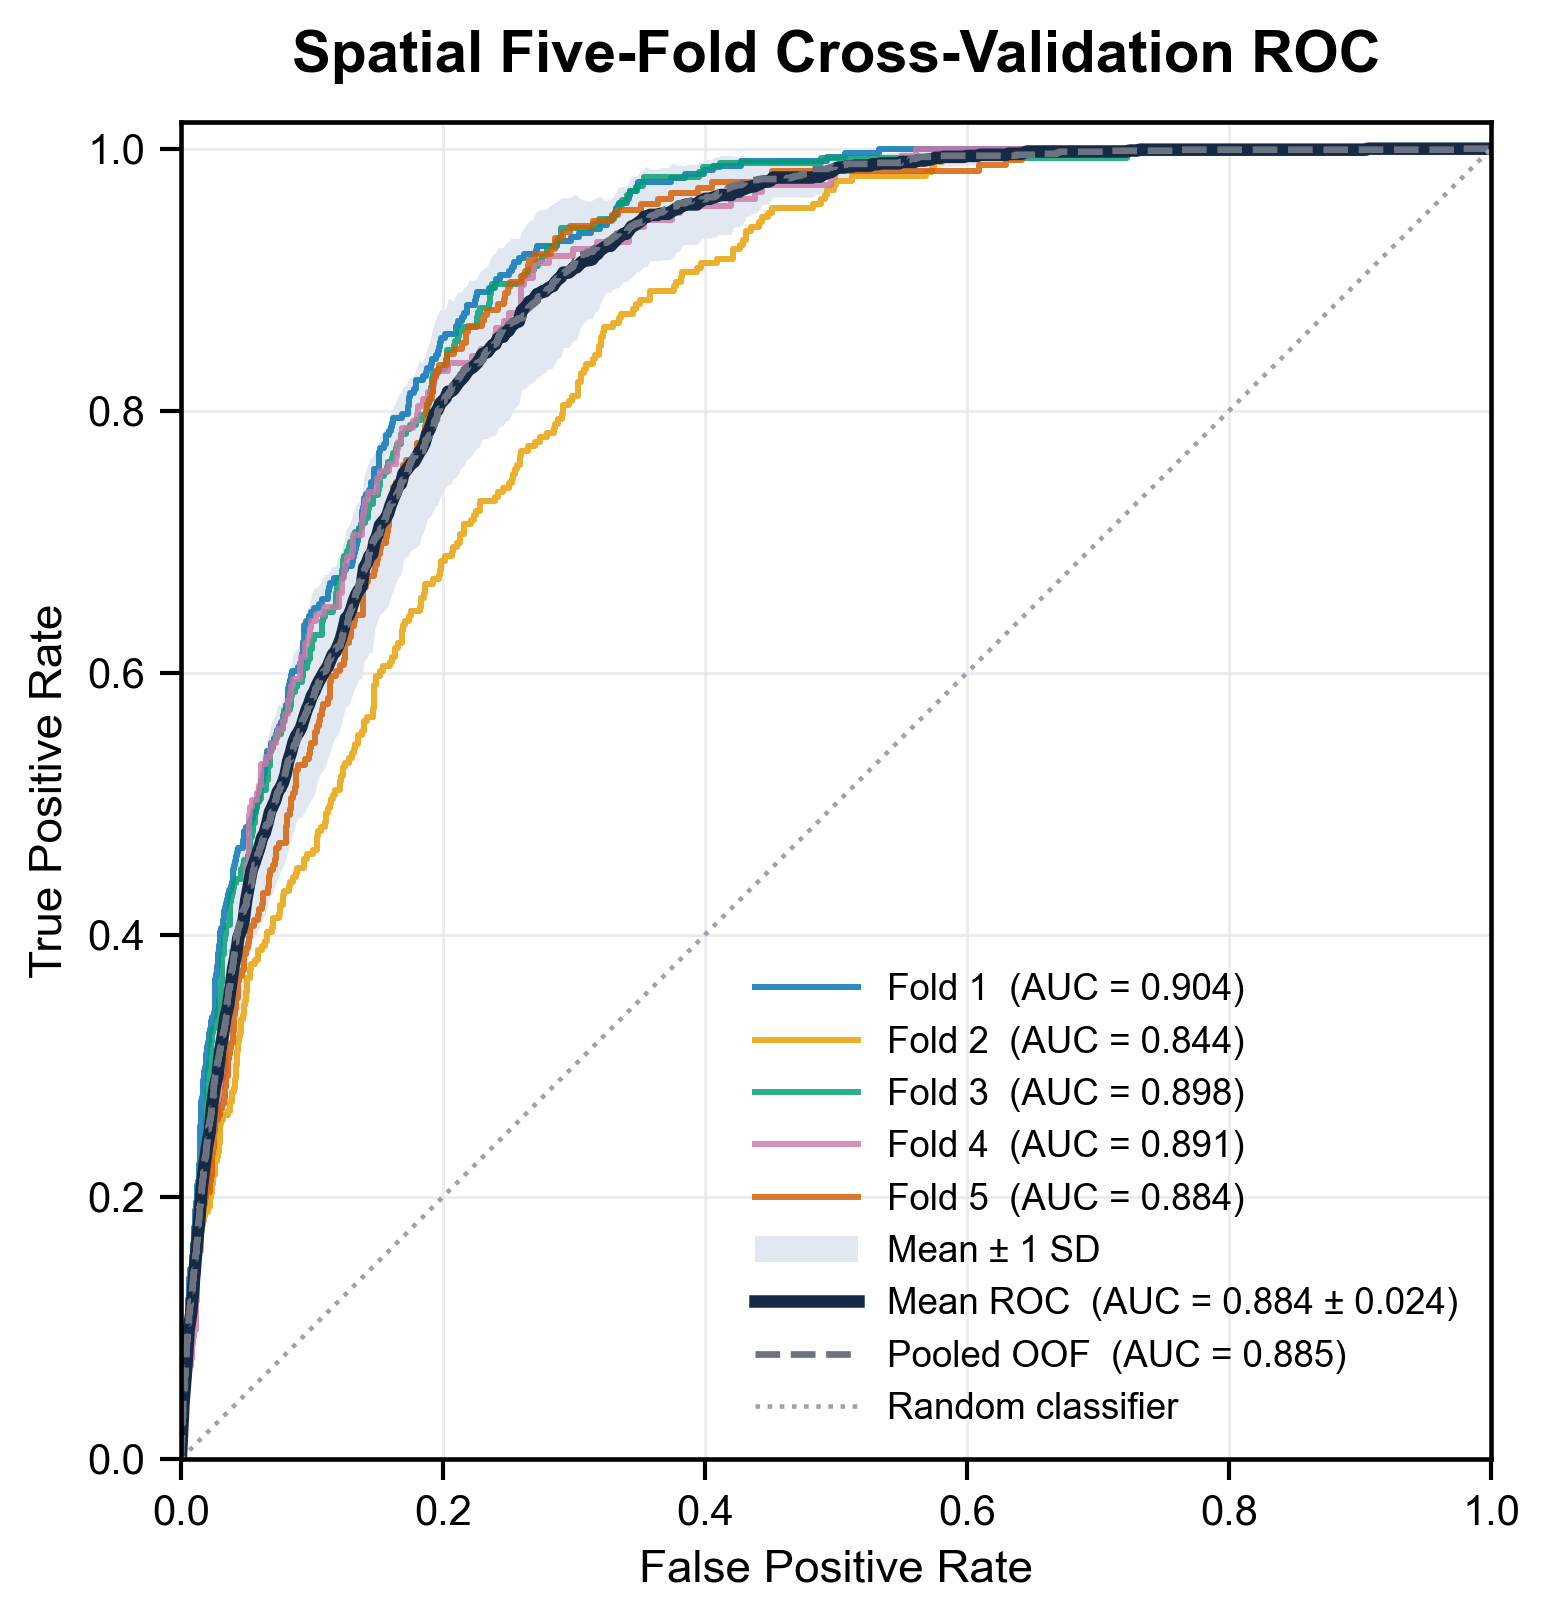

,fold,n_presence,n_background,auc,average_precision
0,1,311,6071,0.904003,0.337227
1,2,286,5694,0.843967,0.229245
2,3,280,6519,0.897674,0.271218
3,4,183,5657,0.890806,0.193730
4,5,236,6059,0.884104,0.223279


Mean fold AUC: 0.884111 ± 0.023643
Pooled spatial OOF AUC: 0.884650
Pooled spatial OOF average precision: 0.251830
Saved: D:\小区光伏物候研究\重做\PV_MaxEnt_upload_outputs\spatial_cross_validation_roc.png


In [6]:
oof = data[["occurrence", "lon", "lat", "fold"]].copy()
oof["oof_prediction"] = best_oof
oof.to_csv(OOF_CSV, index=False, encoding="utf-8-sig")

common_fpr = np.linspace(0, 1, 501)
fold_colors = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]
fold_curves = []
interpolated_tprs = []

for fold in sorted(oof["fold"].unique()):
    subset = oof.loc[oof["fold"] == fold]
    y_true = subset["occurrence"].to_numpy(int)
    y_score = subset["oof_prediction"].to_numpy(float)
    fpr_fold, tpr_fold, _ = roc_curve(y_true, y_score)
    auc_fold = roc_auc_score(y_true, y_score)
    interpolated_tpr = np.interp(common_fpr, fpr_fold, tpr_fold)
    interpolated_tpr[0], interpolated_tpr[-1] = 0.0, 1.0
    fold_curves.append((int(fold), fpr_fold, tpr_fold, auc_fold))
    interpolated_tprs.append(interpolated_tpr)

mean_tpr = np.mean(interpolated_tprs, axis=0)
std_tpr = np.std(interpolated_tprs, axis=0, ddof=1)
mean_tpr[0], mean_tpr[-1] = 0.0, 1.0
mean_auc = best_fold_metrics["auc"].mean()
std_auc = best_fold_metrics["auc"].std(ddof=1)
pooled_auc = roc_auc_score(oof["occurrence"], oof["oof_prediction"])
pooled_ap = average_precision_score(oof["occurrence"], oof["oof_prediction"])

with plt.rc_context({"font.family": "Arial", "axes.linewidth": 1.1}):
    fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=300)
    for (fold, fpr_fold, tpr_fold, auc_fold), color in zip(fold_curves, fold_colors):
        ax.plot(
            fpr_fold, tpr_fold, color=color, lw=1.45, alpha=0.82,
            label=f"Fold {fold + 1}  (AUC = {auc_fold:.3f})",
        )
    ax.fill_between(
        common_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        color="#4C72B0", alpha=0.16, linewidth=0,
        label="Mean ± 1 SD",
    )
    ax.plot(
        common_fpr, mean_tpr, color="#172A45", lw=3,
        label=f"Mean ROC  (AUC = {mean_auc:.3f} ± {std_auc:.3f})",
    )
    pooled_fpr, pooled_tpr, _ = roc_curve(oof["occurrence"], oof["oof_prediction"])
    ax.plot(
        pooled_fpr, pooled_tpr, color="#6B7280", lw=1.6, linestyle="--",
        label=f"Pooled OOF  (AUC = {pooled_auc:.3f})",
    )
    ax.plot([0, 1], [0, 1], color="#9CA3AF", lw=1.1, linestyle=":", label="Random classifier")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_title("Spatial Five-Fold Cross-Validation ROC", fontsize=14, fontweight="bold", pad=12)
    ax.tick_params(axis="both", labelsize=10, width=1, length=5)
    ax.grid(True, color="#E5E7EB", linewidth=0.7, alpha=0.75)
    ax.legend(loc="lower right", frameon=False, fontsize=8.8, handlelength=2.8)
    fig.tight_layout()
    fig.savefig(ROC_FIGURE, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

display(best_fold_metrics)
print(f"Mean fold AUC: {mean_auc:.6f} ± {std_auc:.6f}")
print(f"Pooled spatial OOF AUC: {pooled_auc:.6f}")
print(f"Pooled spatial OOF average precision: {pooled_ap:.6f}")
print(f"Saved: {ROC_FIGURE}")


## 7. Export the validation summary

In [7]:
summary = {
    "method": "Presence-background MaxEnt with uniform study-area background",
    "random_seed": SEED,
    "source_presence_count": int(len(presence_raw)),
    "area_threshold_km2": AREA_THRESHOLD_KM2,
    "filtered_presence_count": int(len(presence)),
    "valid_study_pixels": int(len(full_valid)),
    "background_pool_after_exclusion": int(len(eligible)),
    "background_sample_count": int(len(background)),
    "presence_exclusion_km": PRESENCE_EXCLUSION_KM,
    "spatial_block_degrees": BLOCK_DEGREES,
    "spatial_cv_folds": N_FOLDS,
    "selected_model": best_candidate,
    "spatial_cv_auc_pooled": float(pooled_auc),
    "spatial_cv_auc_mean": float(mean_auc),
    "spatial_cv_auc_sd": float(std_auc),
    "spatial_cv_average_precision_pooled": float(pooled_ap),
    "fold_metrics": best_fold_metrics.to_dict("records"),
}
SUMMARY_JSON.write_text(json.dumps(summary, indent=2), encoding="utf-8")

display(pd.DataFrame([{
    "presence": len(presence),
    "background": len(background),
    "pooled_spatial_auc": pooled_auc,
    "mean_fold_auc": mean_auc,
    "fold_auc_sd": std_auc,
    "pooled_average_precision": pooled_ap,
    "selected_feature_set": best_candidate["name"],
    "beta_multiplier": best_candidate["beta"],
}]))
print(f"Saved: {SUMMARY_JSON}")


,presence,background,pooled_spatial_auc,mean_fold_auc,fold_auc_sd,pooled_average_precision,selected_feature_set,beta_multiplier
0,1296,30000,0.88465,0.884111,0.023643,0.25183,core5,2.0


Saved: D:\小区光伏物候研究\重做\PV_MaxEnt_upload_outputs\validation_summary.json


## Interpretation

- Background points represent the available study-area environment rather than confirmed absences.
- Validation metrics are calculated from spatially out-of-fold predictions.
- Logistic MaxEnt output represents relative suitability under the defined background extent rather than occurrence probability.
